# Plotting with Python

Use `matplotlib` to plot any graph in python

In [24]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import matplotlib.pyplot as plt

## Create an empty canvas to plot

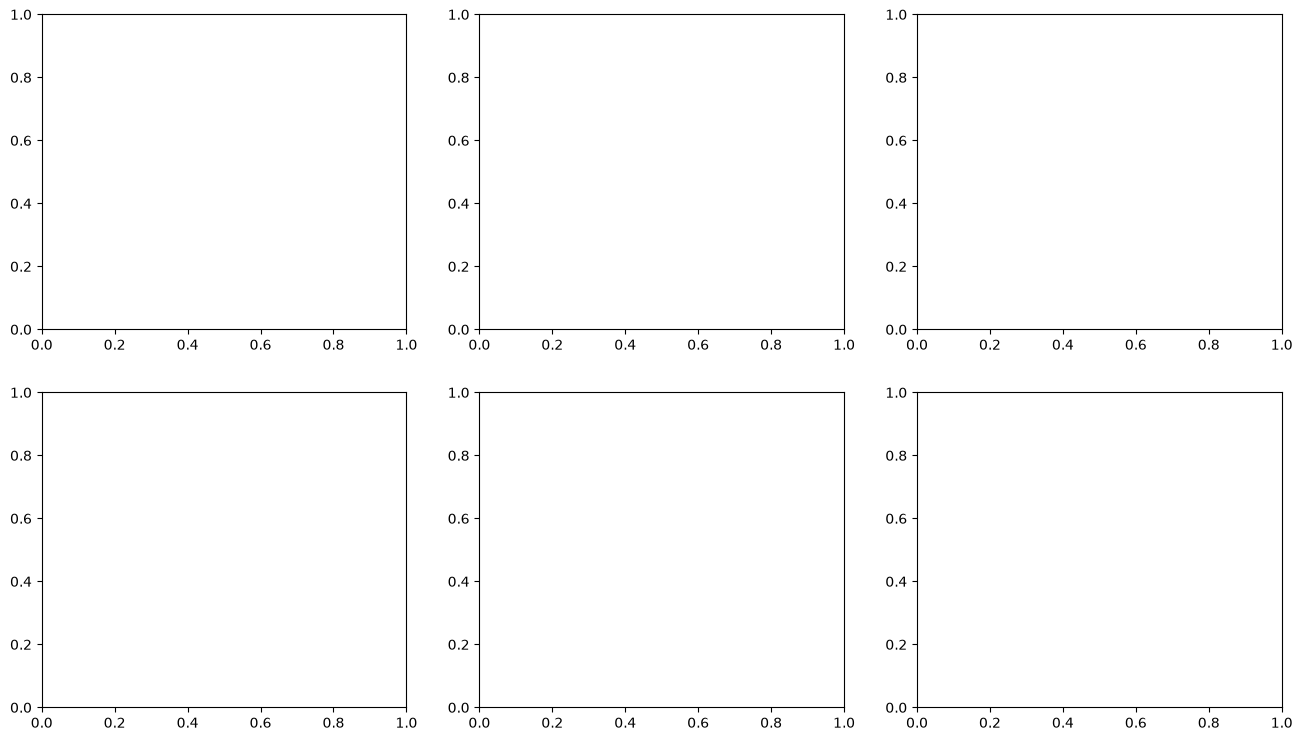

In [3]:
fig, ax = plt.subplots(nrows=2, ncols=3, figsize=(16, 9))

## Rules for graphic (Grammar of graphics)

Each plot should have the following information

- *Data:* What variables are we plotting. FOr example if $y=f(x)$, then we plot $x$ and $y$ values to obtain a curve.
If $z = f(x,y)$, then we plot a surface in $3D$.
- *Mapping:* Which variables go to hich visual channel ($x$ axis, $y$ axis, $z$ axis, color, size)
- *Geometry:* What visual object to represent the data (line, surface, point)
- *Coordinate systems:* Cartesian, polar, or $3D$ plot
- *Scale:* Linear (normal), log, log-log. Set the limit on axis.
- *Facets:* Simple plot vs grid plot (multiple plots at once)
- *Guides:* Labels, legends, title, colorbar.

## Simple plot

Plot a function of single variable: $y = f(x)$ or $x = g(t)$

*Example:* Plot the graph of the function $f(x) = x^2\sqrt{1+e^{-x}}$ on $[0,2]$.
- Use `Numpy` to generate the data: $x$ and $y$ values
- Use `matplotlib` to plot the curve.

In [4]:
import numpy as np
import matplotlib.pyplot as plt

In [5]:
# generate x values
x = np.linspace(0, 2, 100)
print(x.shape)

(100,)


In [6]:
# compute the y value
y = x**2 * np.sqrt(1 + np.exp(-x))
print(y.shape)

(100,)


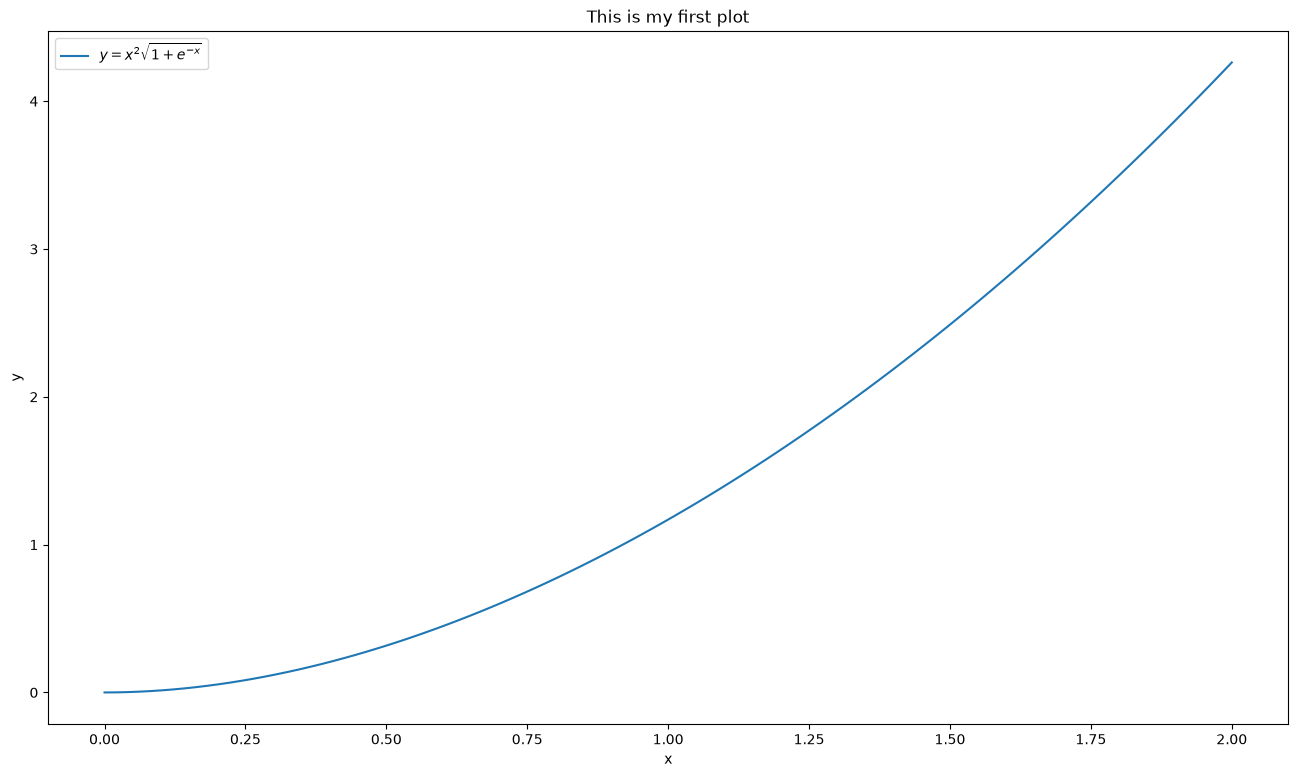

In [7]:
# plot the curve
fig, ax = plt.subplots(figsize=(16, 9))

# plot y = f(X)
ax.plot(x, y, label=r"$y = x^2\sqrt{1 + e^{-x}}$")

# show the legend
ax.legend()

# set x and y axis
ax.set_xlabel("x")
ax.set_ylabel("y")

ax.set_title("This is my first plot")

# show the plot
plt.show()

**Example:** USe the visualization to compare the running time for using pure loop vs numpy vectorization to compute the $cos(v)$.

In [8]:
import math

In [9]:
# compute cos(v) using loops
def compute_cos(v):
    result = []
    for x in v:
        result.append(math.cos(x))
    return result

In [10]:
# create a list of n values from 100 to 1_000_000. Step stepsize=20
n_values = range(100, 100_000, 20)
print(len(n_values))

4995


In [11]:
# create the list to capture the running time
normal_loop_time = []
numpy_time = []

In [12]:
import time

In [13]:
for n in n_values:
    # generate random vector
    v = np.random.uniform(low=1, high=5, size=n)
    v_loop = list(v)
    start_time = time.time()
    cos_v = compute_cos(v_loop)
    end_time = time.time()
    ex_time = end_time - start_time
    normal_loop_time.append(ex_time)
    # use numpy vectorization
    start_time = time.time()
    cos_v = np.cos(v)
    end_time = time.time()
    ex_time = end_time - start_time
    numpy_time.append(ex_time)

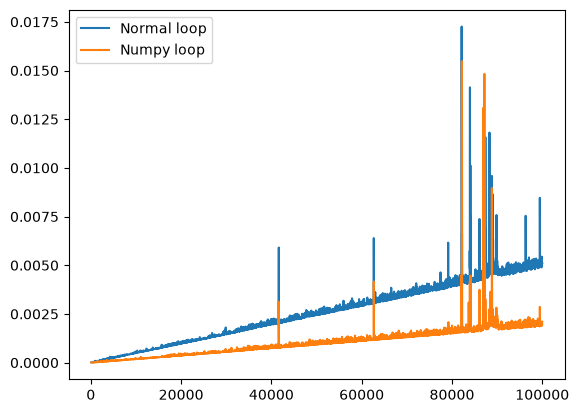

In [14]:
# plot these running times
fig, ax = plt.subplots()
ax.plot(n_values, normal_loop_time, label="Normal loop")
ax.plot(n_values, numpy_time, label="Numpy loop")
ax.legend()
plt.show()

- Numpy performs better in terms of the size of the arrow. If the array is getting bigger, Numpy can handle faster, comparing to the normal loop in Python.

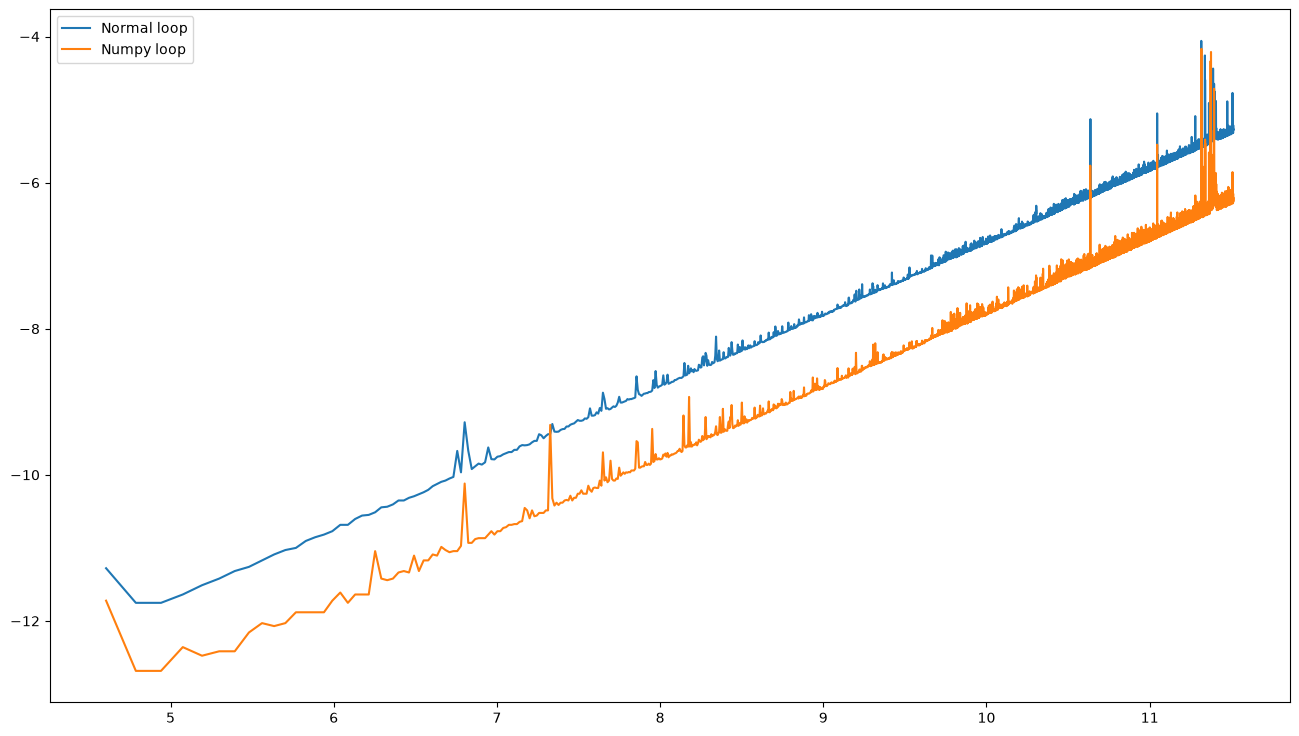

In [15]:
# it could be clearer if we use the log-log plot
fig, axs = plt.subplots(figsize=(16, 9))

axs.plot(np.log(n_values), np.log(normal_loop_time), label="Normal loop")
axs.plot(np.log(n_values), np.log(numpy_time), label="Numpy loop")

axs.legend()

plt.show()

## Plot multiple functions on a single axis

**Example:** Plot these functions $y=\sin(2x)$, $y=\cos(x^2)$, and $y=e^{\sin(x)}$ on the same axis from $-2\pi$ to $2\pi$.

In [16]:
import numpy as np
import matplotlib.pyplot as plt

In [17]:
# define the x values
x = np.linspace(-2*np.pi, 2*np.pi, 200)

In [18]:
# compute the y values for 3 functions
y_1 = np.sin(2*x)
y_2 = np.cos(x**2)
y_3 = np.exp(np.sin(x))

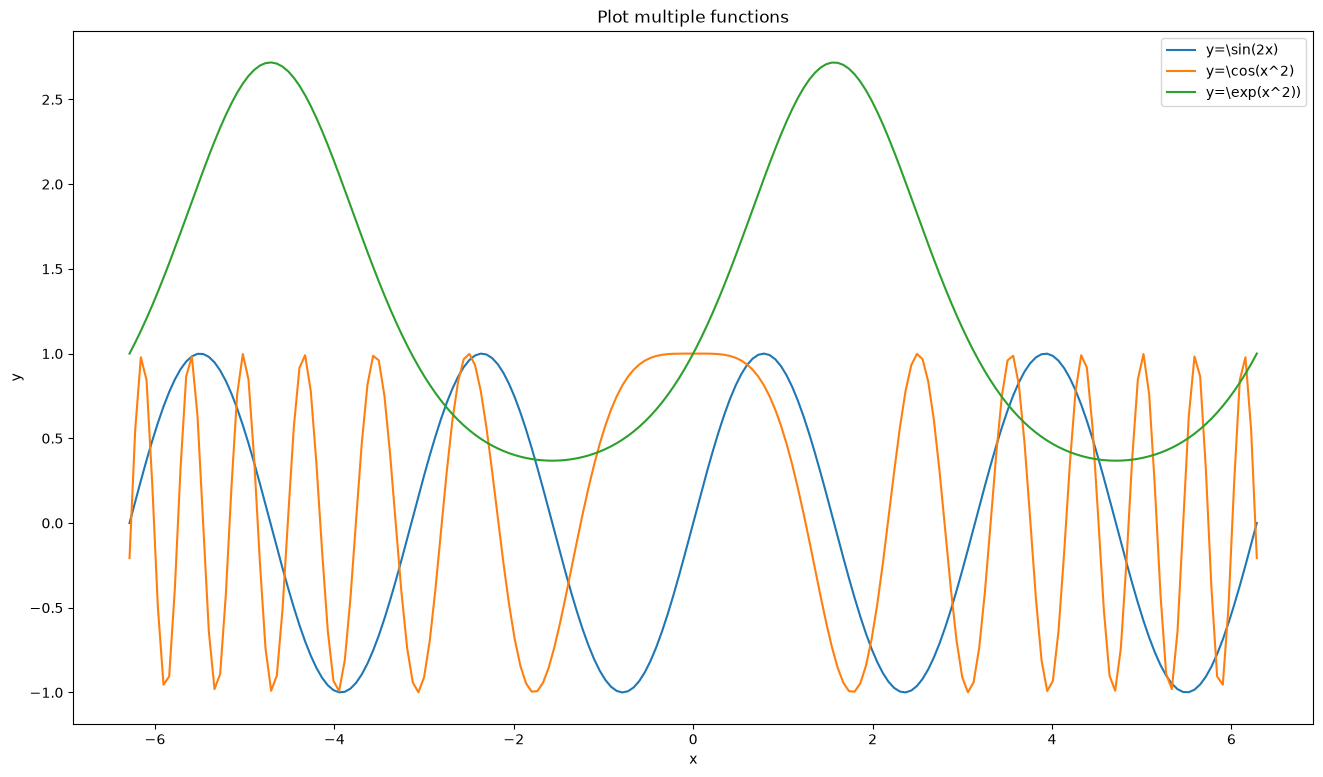

In [23]:
# plot these functions on the same axis
fig, ax = plt.subplots(figsize=(16, 9))

# plot 1st function
ax.plot(x, y_1, label=r"y=\sin(2x)")

# plot the 2nd function
ax.plot(x, y_2, label=r"y=\cos(x^2)")

# plot the 3rd function
ax.plot(x, y_3, label=r"y=\exp(x^2))")

ax.legend()

# set the x and y label
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Plot multiple functions")

plt.show()

## Multiple subplots

Plot multiple functions on different axes.

Syntax
```python
fig, axs = plt.subplot(nrows=m, ncols=n, figsize=(16,9))
```

Notice that $axs$ is the numpy array of axes.

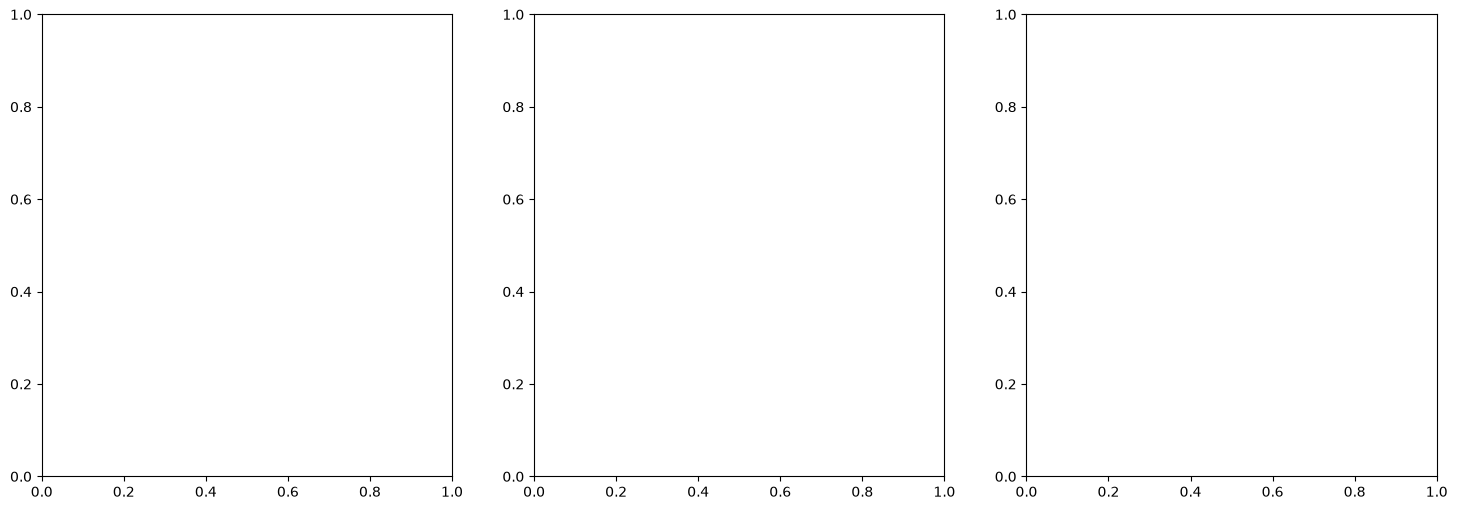

In [34]:
# understand the structure of axs
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(18, 6))

plt.show()

In [35]:
print(type(axs))
print(axs.shape)
print(axs.ndim)

<class 'numpy.ndarray'>
(3,)
1


In [36]:
axs[0]

<Axes: >

**Example:** Plot 3 functions $y=\sin(2x)$, $y=\cos(x^2)$, and $y=e^{\sin(x)}$ from $-2\pi$ to $2\pi$ on different axes.

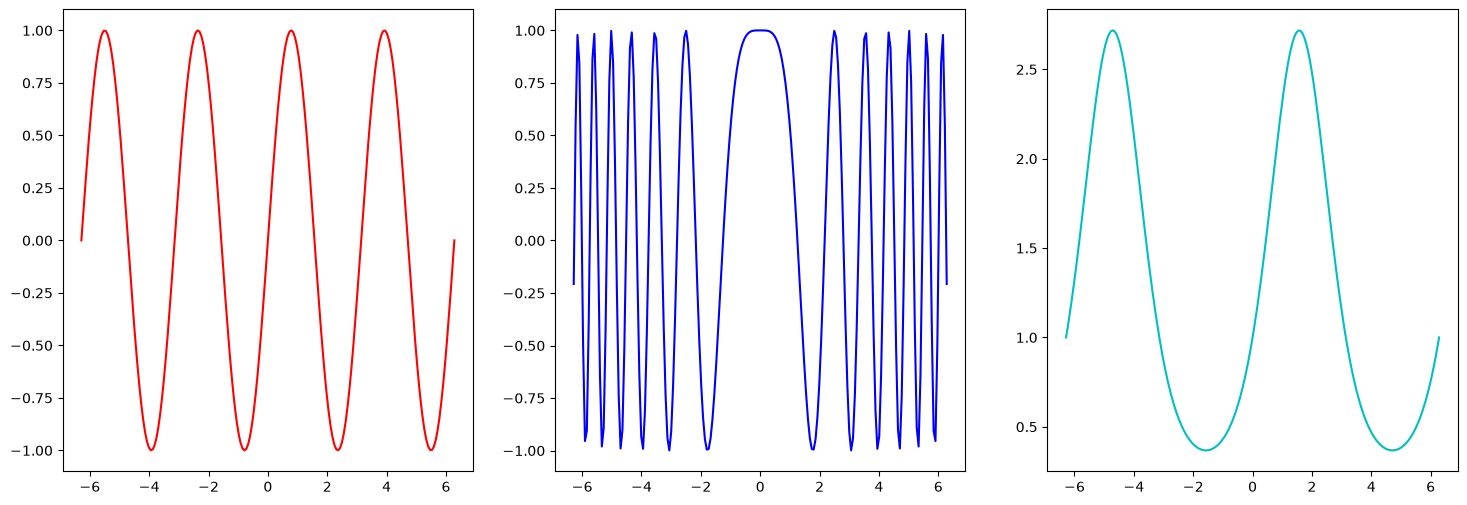

In [42]:
# reuse x, y_1, y_2 and y_3 earlier!!!
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(18, 6))

# plot 1st function on axs 0
axs[0].plot(x, y_1, color="r")

# plot 2nd function on axs 1
axs[1].plot(x, y_2, color="b")

# plot 3rd function on axs 2
axs[2].plot(x, y_3, color="c")

plt.show()

Plot with multiple rows and columns

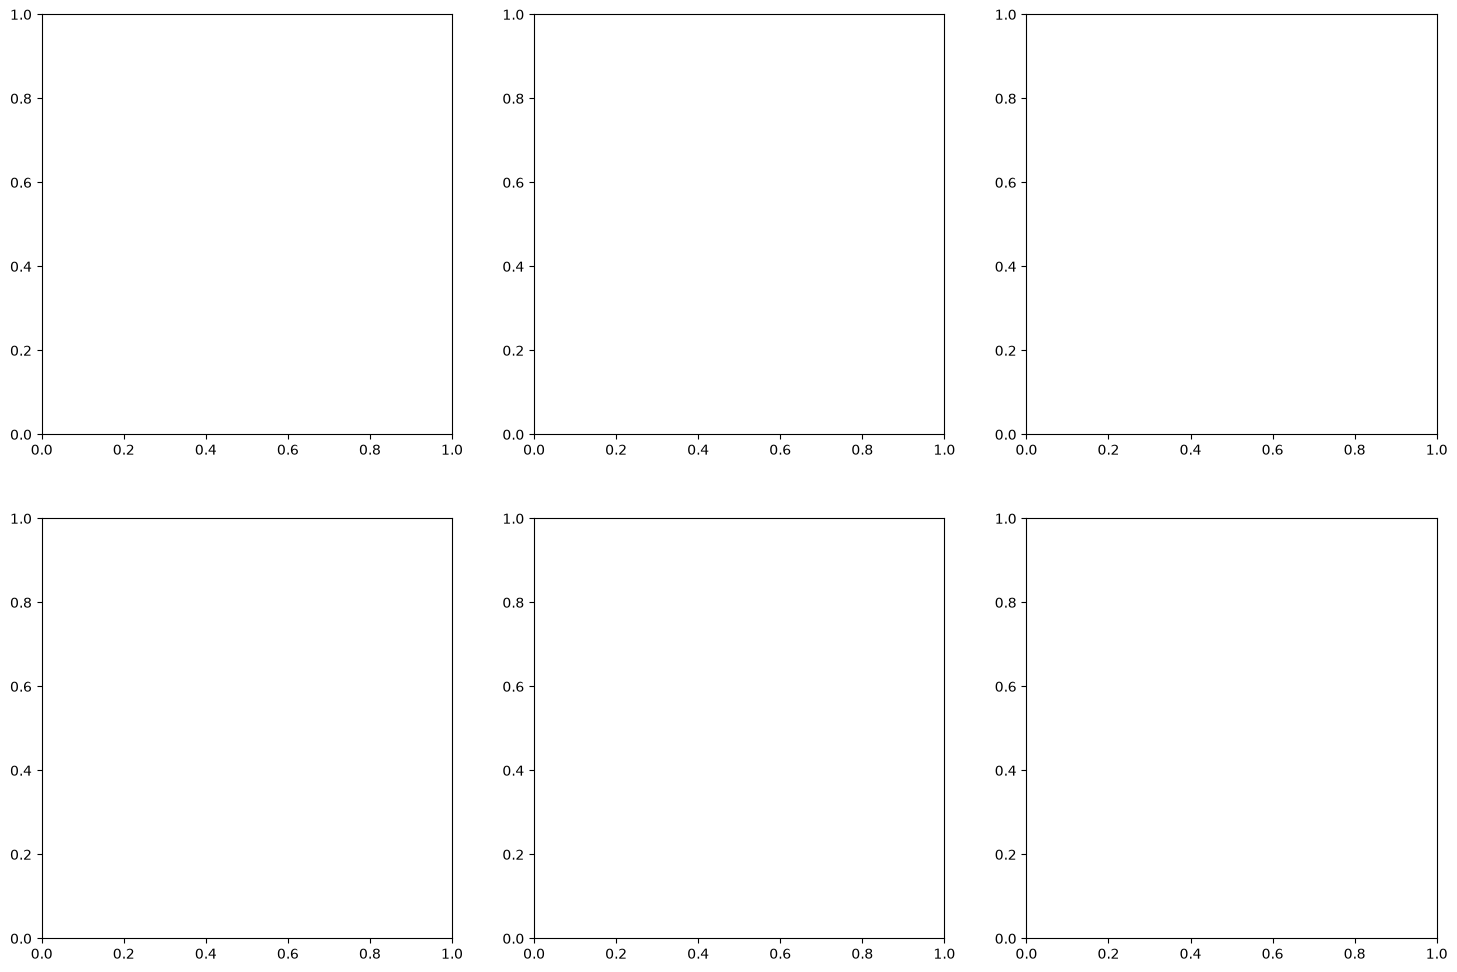

In [45]:
# template
fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(18, 12))

plt.show()

In [46]:
# understand axs
print(axs.ndim)
print(axs.shape)
print(type(axs))

2
(2, 3)
<class 'numpy.ndarray'>


In [47]:
# use double index to get one axis
axs[0,0]

<Axes: >

In [48]:
axs[0]

array([<Axes: >, <Axes: >, <Axes: >], dtype=object)

**Example:** Plot the function $e^{\sin(kx)}$ where $k = 2, 3, 4, 5, 6, 7$ and $x\in [-4,4]$ on the grid $(2,3)$.

In [57]:
x = np.linspace(-4, 4, 100)
y_1 = np.exp(np.sin(2 * x))
y_2 = np.exp(np.sin(3 * x))
y_3 = np.exp(np.sin(4 * x))
y_4 = np.exp(np.sin(5 * x))
y_5 = np.exp(np.sin(6 * x))
y_6 = np.exp(np.sin(7 * x))

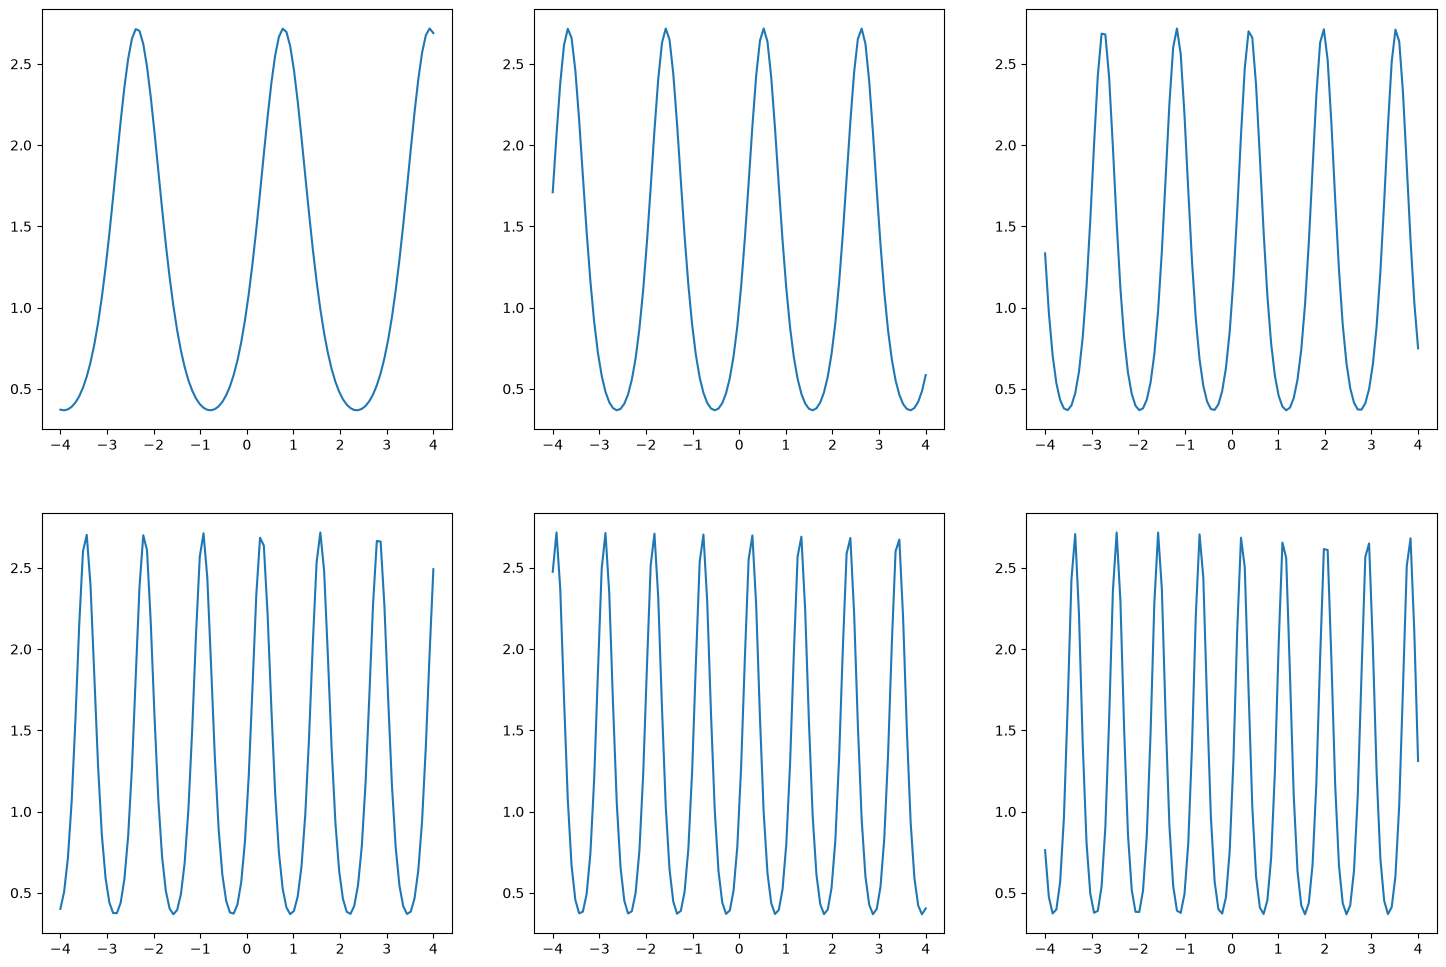

In [58]:
fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(18, 12))

# plot 1st functions at (0,0)
axs[0,0].plot(x, y_1)

axs[0,1].plot(x, y_2)
axs[0,2].plot(x, y_3)

axs[1,0].plot(x, y_4)

axs[1,1].plot(x, y_5)
axs[1,2].plot(x, y_6)

plt.show()

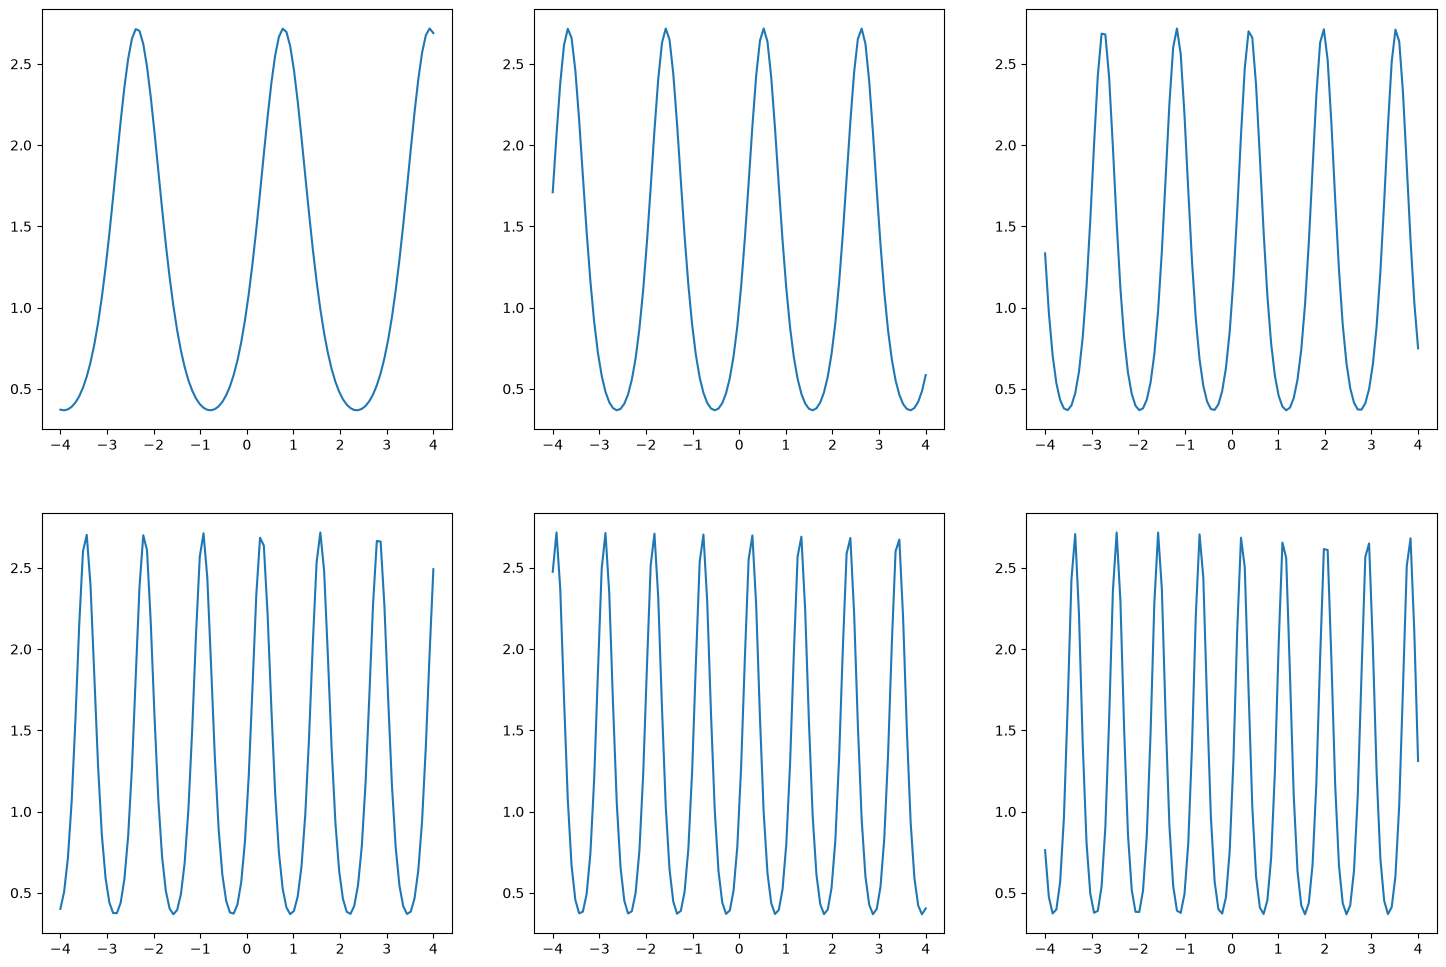

In [59]:
# different approach: use loop
fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(18, 12))

for k in range(2,8):
    y = np.exp(np.sin(k * x))
    row_idx = (k - 2) // 3
    col_idx = (k - 2) % 3
    axs[row_idx, col_idx].plot(x, y)

plt.show()